# Stroke Prediction: TabNet vs TabTransformer

## Install Dependensi

In [ ]:
!pip install pytorch-tabnet kagglehub imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.4 MB/s eta 0:00:00


## 2 — Import Library & Konfigurasi Global

In [ ]:
import gc, time, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import psutil
import tracemalloc
import kagglehub

from sklearn.model_selection    import StratifiedKFold
from sklearn.preprocessing      import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics            import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve, classification_report,
)
from imblearn.over_sampling     import SMOTE
from pytorch_tabnet.tab_model   import TabNetClassifier

warnings.filterwarnings('ignore')

# ── Konstanta global ──────────────────────────────────────────
SEED     = 42
N_SPLITS = 10
CAT_COLS = ['gender', 'hypertension', 'heart_disease', 'ever_married',
            'work_type', 'Residence_type', 'smoking_status']
NUM_COLS = ['age', 'avg_glucose_level', 'bmi']
CLR      = {'No Stroke': '#4A90D9', 'Stroke': '#E84545',
            'TabNet': '#4A90D9',    'TabTransformer': '#2ECC71'}
FT       = {'fontsize': 12, 'fontweight': 'bold'}
DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 110,
                     'axes.spines.top': False, 'axes.spines.right': False})

print(f'Device  : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')

Device  : cuda
GPU     : Tesla T4


## Definisi Kelas MemMonitor

In [ ]:
class MemMonitor:
    def __init__(self, label: str):
        self.label = label
        self._peak_ram   = 0.0
        self._peak_vram  = 0.0

    def start(self):
        gc.collect()
        if DEVICE == 'cuda':
            torch.cuda.reset_peak_memory_stats()
        # Memulai pelacakan alokasi memori internal Python
        tracemalloc.start()

    def stop(self):
        # Mengambil memori tertinggi (puncak) dalam satuan bytes
        _, peak = tracemalloc.get_traced_memory()
        self._peak_ram = peak / (1024 ** 2) # Konversi ke MB
        tracemalloc.stop()

        self._peak_vram = (torch.cuda.max_memory_allocated() / 1024 ** 2
                           if DEVICE == 'cuda' else 0.0)

    def record(self) -> dict:
        d = dict(label     = self.label,
                 ram_peak  = round(self._peak_ram, 1),
                 vram_peak = round(self._peak_vram, 1) if DEVICE == 'cuda' else None)

        tag = f"  [MEM] {self.label}: Peak RAM {d['ram_peak']:.1f} MB"
        if DEVICE == 'cuda':
            tag += f"  |  VRAM Peak {d['vram_peak']:.1f} MB"
        print(tag)
        return d

print('MemMonitor siap dengan pelacakan Peak RAM.')

MemMonitor siap dengan pelacakan Peak RAM.


## Load Dataset

In [ ]:
path   = kagglehub.dataset_download('viviansam/cerebral-stroke-dataset')
df_raw = pd.read_csv(path + '/dataset.csv')

print(f'Ukuran dataset : {df_raw.shape}')

100%|██████████| 560k/560k [00:00<00:00, 37.1MB/s]

Extracting files...


Ukuran dataset : (43400, 12)


## Tampilkan 5 Baris Pertama

In [ ]:
df_raw.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,30669,Male,3.0,0,0,No,children,Rural,95.12,18.0,NaN,0
1,30468,Male,58.0,1,0,Yes,Private,Urban,87.96,39.2,never smoked,0
2,16523,Female,8.0,0,0,No,Private,Urban,110.89,17.6,NaN,0
3,56543,Female,70.0,0,0,Yes,Private,Rural,69.04,35.9,formerly smoked,0
4,46136,Male,14.0,0,0,No,Never_worked,Rural,161.28,19.1,NaN,0


## Info Kolom & Tipe Data

In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43400 entries, 0 to 43399
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 43400 non-null  int64  
 1   gender             43400 non-null  object 
 2   age                43400 non-null  float64
 3   hypertension       43400 non-null  int64  
 4   heart_disease      43400 non-null  int64  
 5   ever_married       43400 non-null  object 
 6   work_type          43400 non-null  object 
 7   Residence_type     43400 non-null  object 
 8   avg_glucose_level  43400 non-null  float64
 9   bmi                41938 non-null  float64
 10  smoking_status     30108 non-null  object 
 11  stroke             43400 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 4.0+ MB


## Cek Nilai Hilang (Missing Values)

In [ ]:
missing = df_raw.isnull().sum()
print('Nilai hilang per kolom:')
print(missing[missing > 0])

Nilai hilang per kolom:
bmi                1462
smoking_status    13292
dtype: int64


## Statistik Deskriptif

In [ ]:
df_raw.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,43400.000000,43400.000000,43400.000000,43400.000000,43400.000000,41938.000000,43400.000000
mean,36326.142350,42.217894,0.093571,0.047512,104.482750,28.605038,0.018041
std,21072.134879,22.519649,0.291235,0.212733,43.111751,7.770020,0.133103
min,1.000000,0.080000,0.000000,0.000000,55.000000,10.100000,0.000000
25%,18038.500000,24.000000,0.000000,0.000000,77.540000,23.200000,0.000000
50%,36351.500000,44.000000,0.000000,0.000000,91.580000,27.700000,0.000000
75%,54514.250000,60.000000,0.000000,0.000000,112.070000,32.900000,0.000000
max,72943.000000,82.000000,1.000000,1.000000,291.050000,97.600000,1.000000


## EDA: Distribusi Target & Histogram Numerik

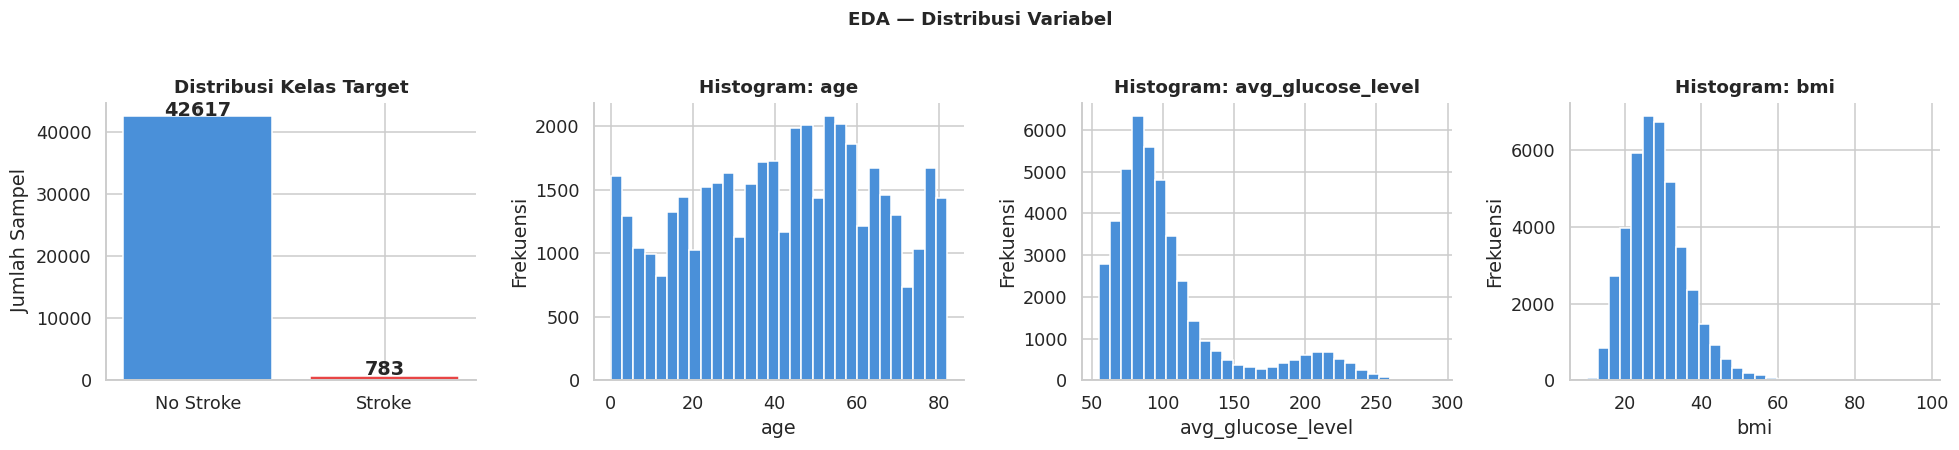

In [ ]:
df_ = df_raw.copy()
df_['Kelas'] = df_['stroke'].map({0: 'No Stroke', 1: 'Stroke'})

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
counts = df_raw['stroke'].value_counts()
axes[0].bar(['No Stroke', 'Stroke'], counts.values,
            color=[CLR['No Stroke'], CLR['Stroke']], edgecolor='white')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')
axes[0].set_title('Distribusi Kelas Target', **FT)
axes[0].set_ylabel('Jumlah Sampel')

for ax, col in zip(axes[1:], NUM_COLS):
    ax.hist(df_raw[col].dropna(), bins=30, color=CLR['TabNet'], edgecolor='white')
    ax.set_title(f'Histogram: {col}', **FT)
    ax.set_xlabel(col); ax.set_ylabel('Frekuensi')

plt.suptitle('EDA — Distribusi Variabel', **FT, y=1.02)
plt.tight_layout()
plt.show()

## EDA: Analisis Outlier (Boxplot)

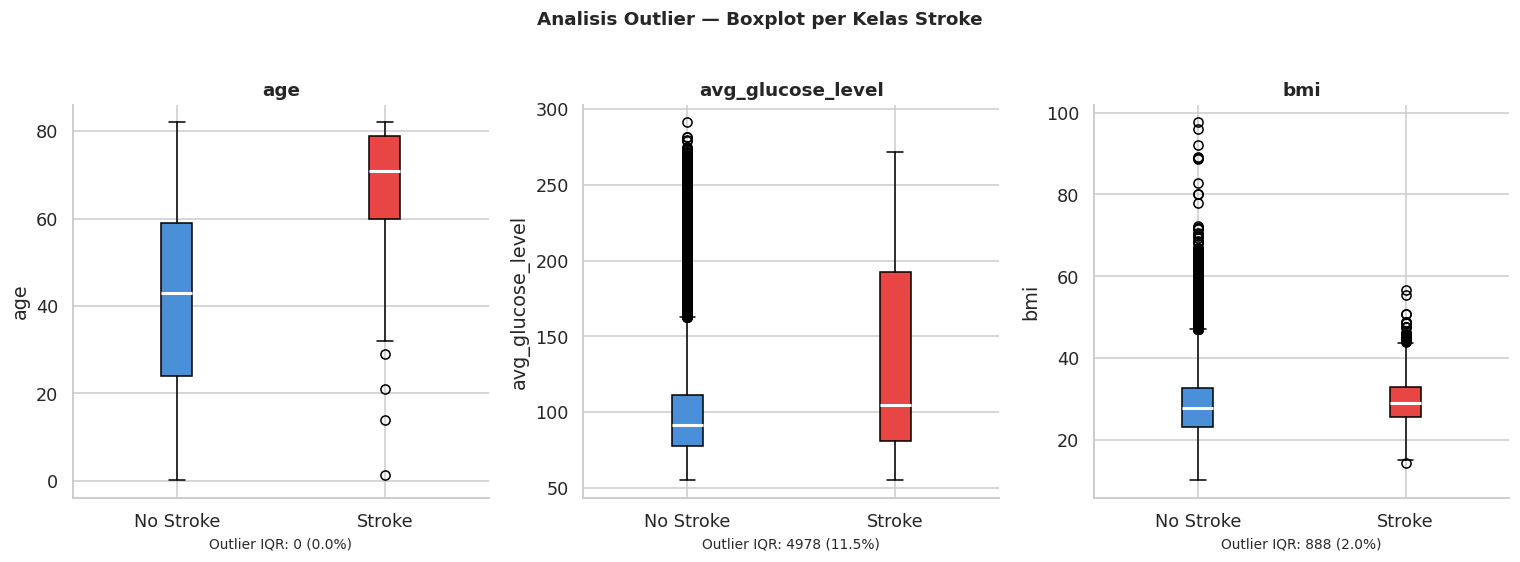

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col in zip(axes, NUM_COLS):
    grps = [df_.loc[df_['Kelas'] == k, col].dropna()
            for k in ['No Stroke', 'Stroke']]
    bp = ax.boxplot(grps, patch_artist=True,
                    medianprops=dict(color='white', linewidth=2))
    bp['boxes'][0].set_facecolor(CLR['No Stroke'])
    bp['boxes'][1].set_facecolor(CLR['Stroke'])
    ax.set_xticklabels(['No Stroke', 'Stroke'])
    ax.set_title(col, **FT); ax.set_ylabel(col)

    q1, q3 = df_raw[col].quantile([0.25, 0.75])
    n_out  = ((df_raw[col] < q1-1.5*(q3-q1)) | (df_raw[col] > q3+1.5*(q3-q1))).sum()
    ax.set_xlabel(f'Outlier IQR: {n_out} ({n_out/len(df_raw)*100:.1f}%)', fontsize=9)

plt.suptitle('Analisis Outlier — Boxplot per Kelas Stroke', **FT, y=1.02)
plt.tight_layout()
plt.show()

## EDA: Analisis Multivariat (Violin + Scatter)

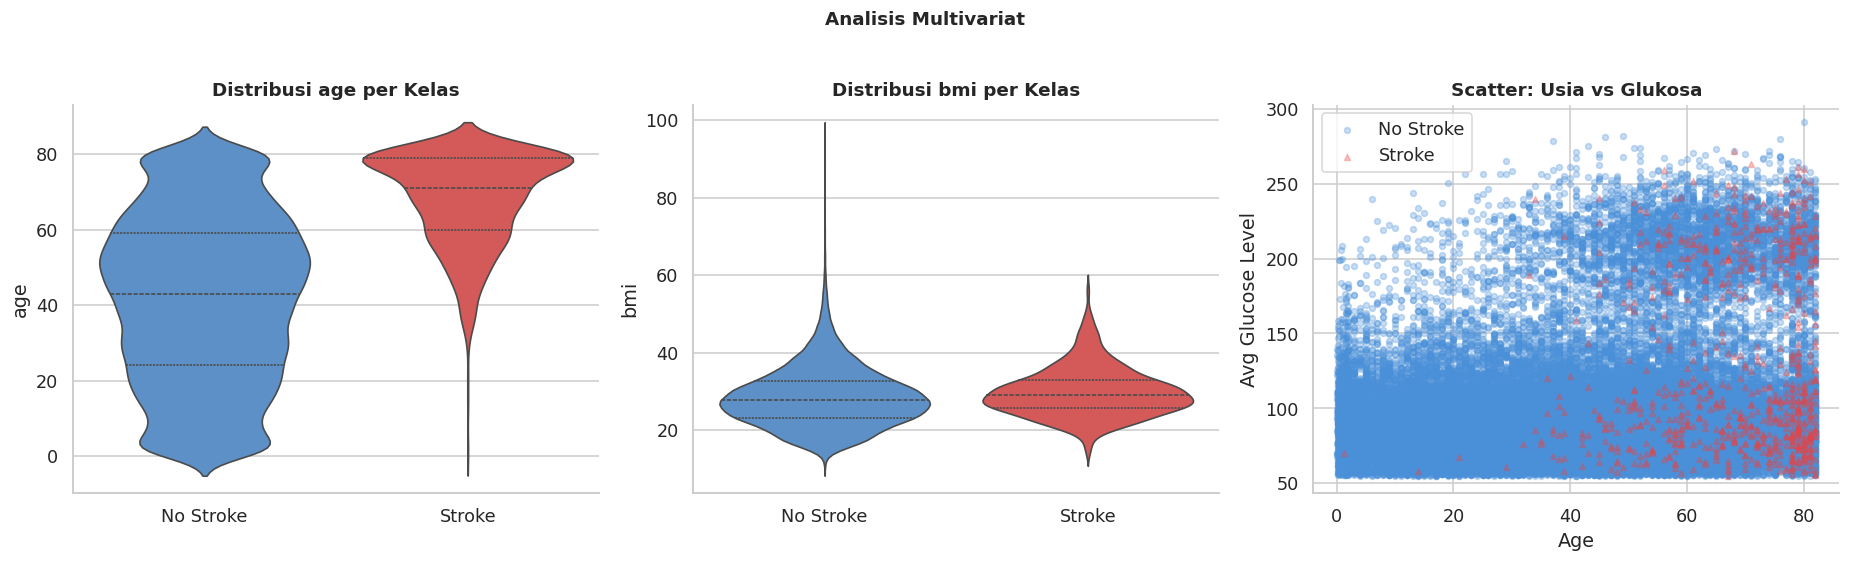

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, col in zip(axes[:2], ['age', 'bmi']):
    sns.violinplot(data=df_, x='Kelas', y=col, ax=ax,
                   palette=CLR, inner='quartile', linewidth=1.1)
    ax.set_title(f'Distribusi {col} per Kelas', **FT)
    ax.set_xlabel(''); ax.set_ylabel(col)

for label in ['No Stroke', 'Stroke']:
    mask = df_['Kelas'] == label
    axes[2].scatter(df_.loc[mask, 'age'], df_.loc[mask, 'avg_glucose_level'],
                    c=CLR[label], alpha=0.3, s=15, label=label,
                    marker=('o' if label == 'No Stroke' else '^'))
axes[2].set_xlabel('Age'); axes[2].set_ylabel('Avg Glucose Level')
axes[2].set_title('Scatter: Usia vs Glukosa', **FT)
axes[2].legend()

plt.suptitle('Analisis Multivariat', **FT, y=1.02)
plt.tight_layout()
plt.show()

## EDA: Tingkat Stroke per Kategori Fitur

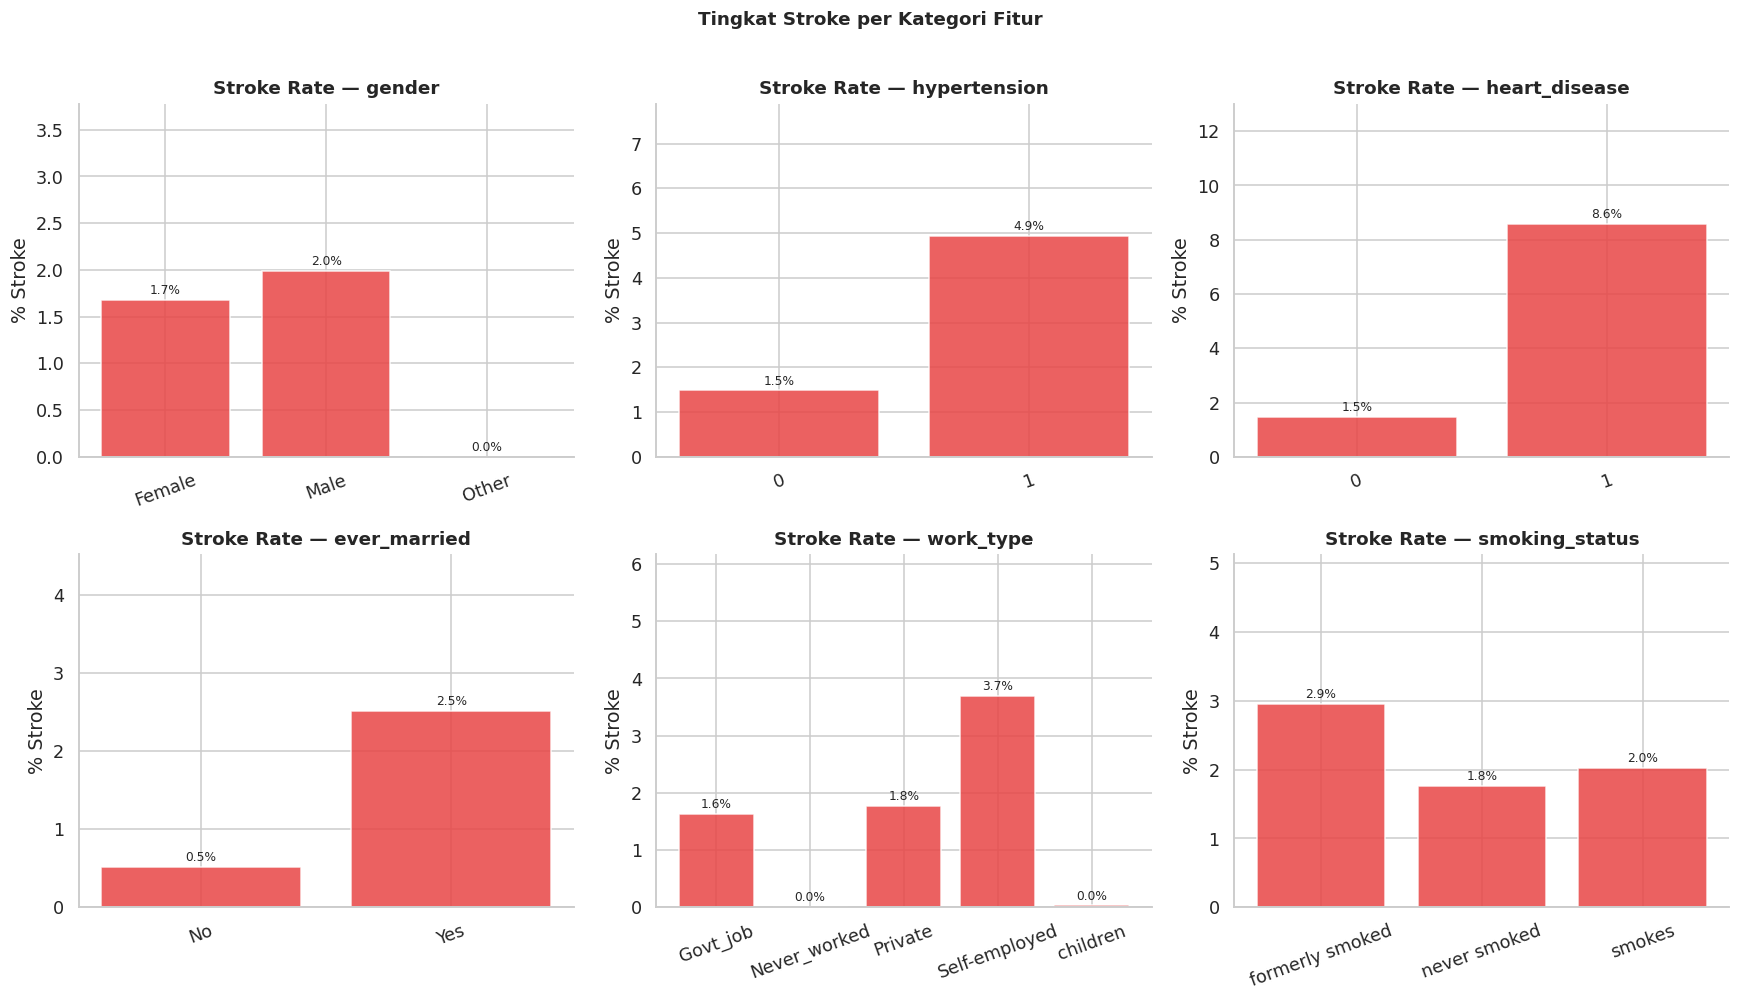

In [ ]:
cat_plot = ['gender', 'hypertension', 'heart_disease',
            'ever_married', 'work_type', 'smoking_status']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), cat_plot):
    pv = (df_raw.groupby(col)['stroke'].mean()
              .reset_index()
              .rename(columns={'stroke': 'pct'}))
    pv['pct'] *= 100
    bars = ax.bar(pv[col].astype(str), pv['pct'],
                  color=CLR['Stroke'], edgecolor='white', alpha=0.85)
    ax.bar_label(bars, fmt='%.1f%%', padding=2, fontsize=8)
    ax.set_title(f'Stroke Rate — {col}', **FT)
    ax.set_ylabel('% Stroke'); ax.tick_params(axis='x', rotation=20)
    ax.set_ylim(0, pv['pct'].max() * 1.4 + 1)

plt.suptitle('Tingkat Stroke per Kategori Fitur', **FT, y=1.01)
plt.tight_layout()
plt.show()

## EDA: Matriks Korelasi & Pemeriksaan Data Leakage


  ✓ Tidak ada indikasi kebocoran data secara statistik.


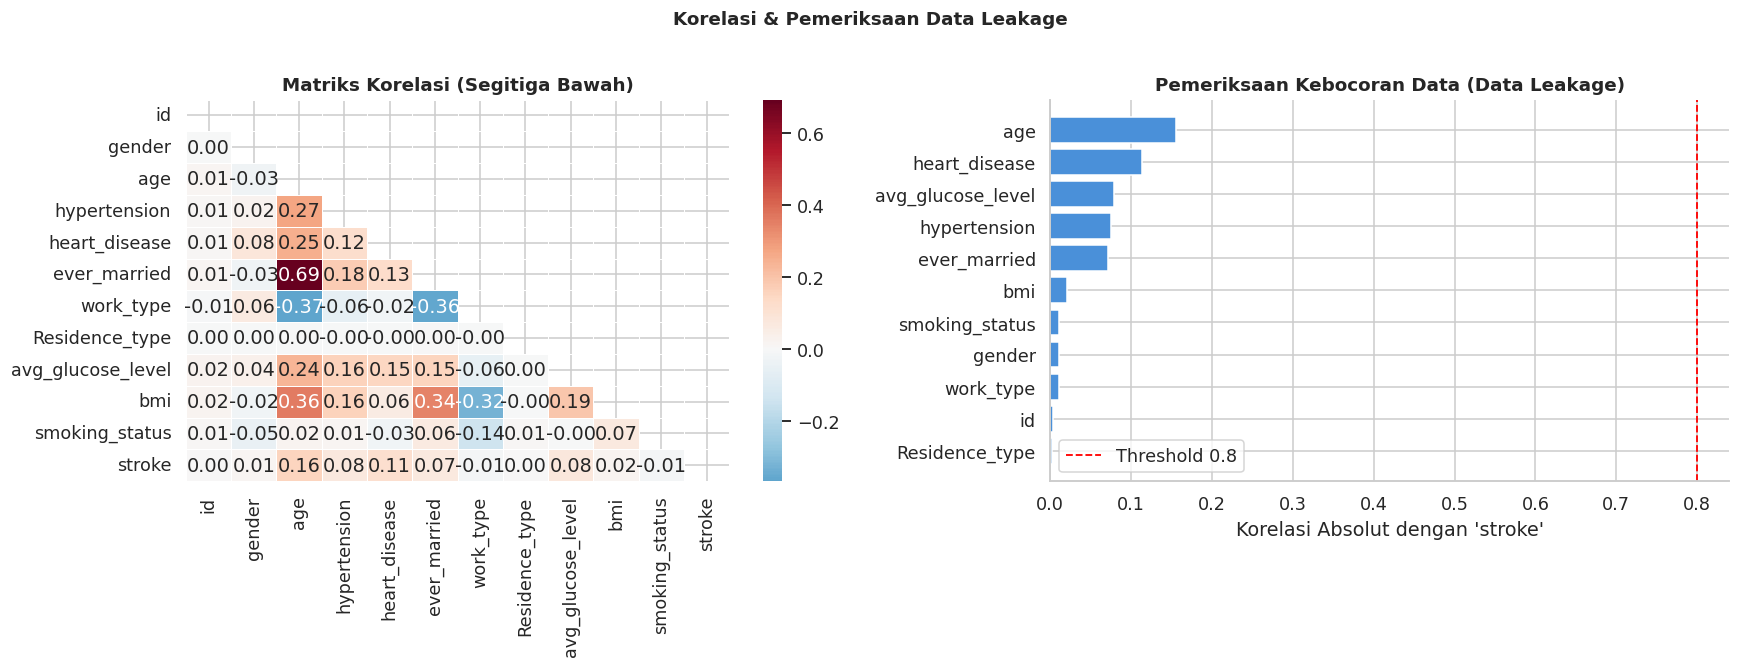

In [ ]:
corr_df = df_raw.copy()
for col in corr_df.select_dtypes('object').columns:
    corr_df[col] = LabelEncoder().fit_transform(corr_df[col].astype(str))
corr_mat = corr_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(corr_mat, annot=True, cmap='RdBu_r', fmt='.2f', center=0,
            mask=np.triu(np.ones_like(corr_mat, dtype=bool)),
            linewidths=0.4, ax=axes[0])
axes[0].set_title('Matriks Korelasi (Segitiga Bawah)', **FT)

corr_tgt   = corr_mat['stroke'].drop('stroke').abs().sort_values(ascending=True)
colors_bar = [CLR['Stroke'] if v > 0.8 else CLR['TabNet'] for v in corr_tgt]
axes[1].barh(corr_tgt.index, corr_tgt.values, color=colors_bar)
axes[1].axvline(0.8, color='red', ls='--', lw=1.2, label='Threshold 0.8')
axes[1].set_xlabel("Korelasi Absolut dengan 'stroke'")
axes[1].set_title('Pemeriksaan Kebocoran Data (Data Leakage)', **FT)
axes[1].legend()

leaky   = corr_tgt[corr_tgt > 0.8]
verdict = ('\u26a0 Ada fitur dengan korelasi > 0.8 — perlu diperiksa lebih lanjut.'
           if not leaky.empty
           else '\u2713 Tidak ada indikasi kebocoran data secara statistik.')
print(f'\n  {verdict}')

plt.suptitle('Korelasi & Pemeriksaan Data Leakage', **FT, y=1.01)
plt.tight_layout()
plt.show()

## Preprocessing (Imputasi + Label Encoding + SMOTE + Scaling)

In [ ]:
df_prep = df_raw.drop('id', axis=1, errors='ignore').copy()

# Imputasi
df_prep['bmi']            = df_prep['bmi'].fillna(df_prep['bmi'].median())
df_prep['smoking_status'] = df_prep['smoking_status'].fillna('Unknown')

# Label Encoding
cat_dims = []
for col in CAT_COLS:
    le = LabelEncoder()
    df_prep[col] = le.fit_transform(df_prep[col].astype(str))
    cat_dims.append(df_prep[col].nunique())

X_raw = df_prep[CAT_COLS + NUM_COLS].values
y_raw = df_prep['stroke'].values

print(f'Sebelum SMOTE : {dict(zip(*np.unique(y_raw, return_counts=True)))}')

Sebelum SMOTE : {np.int64(0): np.int64(42617), np.int64(1): np.int64(783)}


## SMOTE & StandardScaler

In [ ]:
print('[Preprocessing] SMOTE — menangani ketidakseimbangan kelas ...')
X_smote, y_smote = SMOTE(random_state=SEED).fit_resample(X_raw, y_raw)
print(f'  Distribusi setelah SMOTE : {dict(zip(*np.unique(y_smote, return_counts=True)))}')

print('[Preprocessing] StandardScaler — normalisasi fitur numerik ...')
X_final = X_smote.astype(float)
X_final[:, len(CAT_COLS):] = StandardScaler().fit_transform(X_final[:, len(CAT_COLS):])

y_final = y_smote

print(f'  Dataset final : {X_final.shape[0]:,} sampel \u00d7 {X_final.shape[1]} fitur')
print(f'  cat_dims      : {cat_dims}')

[Preprocessing] SMOTE — menangani ketidakseimbangan kelas ...
  Distribusi setelah SMOTE : {np.int64(0): np.int64(42617), np.int64(1): np.int64(42617)}
[Preprocessing] StandardScaler — normalisasi fitur numerik ...
  Dataset final : 85,234 sampel × 10 fitur
  cat_dims      : [3, 2, 2, 2, 5, 2, 4]


## Definisi Arsitektur Model (TabTransformer & Dataset)

In [ ]:
class TabTransformerAuthentic(nn.Module):

    def __init__(self, cat_dims, num_count, embed_dim=64, depth=6, nhead=8):
        super().__init__()
        # cat_dims: jumlah kategori unik tiap fitur kategorikal
        self.embeddings = nn.ModuleList(                     #Pada tahap ini data kategorikal seperti gender, status pernikahan, jenis pekerjaan,
            [nn.Embedding(d, embed_dim) for d in cat_dims])  #dan status merokok diubah terlebih dahulu menjadi representasi numerik yang dapat dipahami model.

        # Encoder transformer standar: fitur kategorikal diperlakukan sebagai "token"
        # nhead: jumlah attention head paralel; depth: jumlah layer ditumpuk
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=nhead,
            dim_feedforward=embed_dim * 4,
            batch_first=True, dropout=0.1)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=depth) # tumpuk beberapa encoder layer

        self.num_norm = nn.LayerNorm(num_count)  # normalisasi ulang fitur numerik sebelum digabung
        self.mlp = nn.Sequential( #model yang telah digabungkan diteruskan ke mlp untuk menghasilkan prediksi akhir
            # input = (semua fitur kategorikal setelah transformer) + (fitur numerik)
            nn.Linear(len(cat_dims) * embed_dim + num_count, 256),
            nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 2))

    def forward(self, x_cat, x_num):
        # ambil embedding tiap kolom kategorikal, lalu susun jadi "sequence" (batch, n_fitur, embed_dim)
        x = torch.stack(
            [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)], dim=1)
        x = self.transformer(x).flatten(1)
        # gabung hasil transformer (kategorikal) dengan fitur numerik ternormalisasi, lalu klasifikasi
        return self.mlp(torch.cat([x, self.num_norm(x_num)], dim=1))


class StrokeDataset(torch.utils.data.Dataset):

    def __init__(self, X, y, n_cat):
        # pisahkan array gabungan X jadi bagian kategorikal & numerik
        self.xc = torch.tensor(X[:, :n_cat], dtype=torch.long) # long: dipakai sbg indeks embedding
        self.xn = torch.tensor(X[:, n_cat:],  dtype=torch.float32) # float: fitur numerik biasa
        self.y  = torch.tensor(y,              dtype=torch.long) # label kelas (untuk CrossEntropyLoss)

    def __len__(self):          return len(self.y)
    def __getitem__(self, idx): return self.xc[idx], self.xn[idx], self.y[idx]


print('Arsitektur TabTransformerAuthentic & StrokeDataset siap.')

Arsitektur TabTransformerAuthentic & StrokeDataset siap.


## Fungsi Helper (Threshold, Inferensi, Metrik)

In [ ]:
def _optimal_threshold(y_true, probs):

    fpr, tpr, ths = roc_curve(y_true, probs)
    return ths[np.argmax(tpr - fpr)]


def _infer_tt(model, X):

    model.eval()
    with torch.no_grad(): # nonaktifkan perhitungan gradien (tidak perlu saat prediksi)
        # pisahkan kembali data jadi bagian kategorikal & numerik, pindahkan ke device
        xc = torch.tensor(X[:, :len(CAT_COLS)], dtype=torch.long).to(DEVICE)
        xn = torch.tensor(X[:, len(CAT_COLS):], dtype=torch.float32).to(DEVICE)
        # softmax ubah output mentah jadi probabilitas; ambil kolom kelas "Stroke" (indeks 1)
        return torch.softmax(model(xc, xn), dim=1)[:, 1].cpu().numpy()


def _metrics(y_true, y_pred, y_prob, elapsed) -> dict:
    # kumpulkan semua metrik evaluasi jadi satu dictionary
    return dict(Accuracy  = accuracy_score(y_true, y_pred),                     # persentase tebakan benar
                Precision = precision_score(y_true, y_pred, zero_division=0),   # ketepatan saat prediksi "Stroke"
                Recall    = recall_score(y_true, y_pred, zero_division=0),      # kemampuan menangkap kasus Stroke yang sebenarnya
                F1        = f1_score(y_true, y_pred, zero_division=0),          # gabungan Precision & Recall
                AUC       = roc_auc_score(y_true, y_prob),                      # kemampuan model membedakan kelas (pakai probabilitas)
                Time      = elapsed)                                            # waktu training (detik)


print('Fungsi helper siap.')

Fungsi helper siap.


## Fungsi Pelatihan TabNet & TabTransformer

In [ ]:
def train_tabnet(X_tr, y_tr, X_val, y_val, cw, mem: MemMonitor):

    mem.start()         # mulai catat pemakaian RAM/VRAM
    t0 = time.time()    # catat waktu mulai training

    # buat model TabNet dengan konfigurasi arsitektur & optimizer
    model = TabNetClassifier(
        n_d=32, n_a=32,       # ukuran dimensi decision & attention layer
        n_steps=5,            # jumlah langkah pengambilan keputusan bertahap
        gamma=1.3,            # kontrol seberapa besar fitur bisa dipakai ulang antar step
        lambda_sparse=1e-3,   # penalti agar model memilih fitur secara selektif
        optimizer_params=dict(lr=2e-2), verbose=0)

    # latih model; otomatis berhenti (early stopping) jika tak membaik setelah 15 epoch
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
              max_epochs=100, patience=15,
              weights={i: cw[i] for i in range(len(cw))})

    elapsed = time.time() - t0  # hitung total waktu training
    mem.stop()                  # hentikan pencatat memori, simpan hasil peak RAM/VRAM
    prob  = model.predict_proba(X_val)[:, 1]                        # ambil probabilitas kelas "Stroke"
    pred  = (prob >= _optimal_threshold(y_val, prob)).astype(int)   # ubah ke label 0/1 pakai threshold optimal
    return pred, prob, elapsed


def train_tabtransformer(X_tr, y_tr, X_val, y_val, cat_dims, cw_tensor, mem: MemMonitor):

    mem.start()
    t0 = time.time()

    # DataLoader: bagi data training jadi batch berisi 256 sampel, diacak tiap epoch
    loader    = torch.utils.data.DataLoader(
        StrokeDataset(X_tr, y_tr, len(CAT_COLS)),
        batch_size=256, shuffle=True)
    model     = TabTransformerAuthentic(cat_dims, len(NUM_COLS)).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)                 # optimizer Adam untuk update bobot
    criterion = nn.CrossEntropyLoss(weight=cw_tensor)                         # loss function, beri bobot ke kelas minoritas

    model.train()
    for _ in range(50):              # ulangi training sebanyak 50 epoch
        for xc, xn, yb in loader:
            xc, xn, yb = xc.to(DEVICE), xn.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            criterion(model(xc, xn), yb).backward()
            optimizer.step()

    elapsed = time.time() - t0
    mem.stop()
    prob  = _infer_tt(model, X_val)                                   # prediksi probabilitas di data validasi
    pred  = (prob >= _optimal_threshold(y_val, prob)).astype(int)     # ubah ke label 0/1 pakai threshold optimal
    return pred, prob, elapsed


print('Fungsi pelatihan TabNet & TabTransformer siap.')

Fungsi pelatihan TabNet & TabTransformer siap.


## Inisialisasi Struktur K-Fold

In [ ]:
MODELS       = ['TabNet', 'TabTransformer']
skf          = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
accum        = {m: {'y_true': [], 'y_pred': [], 'y_prob': []} for m in MODELS}
fold_metrics = {m: [] for m in MODELS}
mem_log      = {m: [] for m in MODELS}

folds_list   = list(skf.split(X_final, y_final))   # simpan semua split

print(f'{N_SPLITS}-Fold split siap. Total sampel: {len(y_final):,}')

10-Fold split siap. Total sampel: 85,234


## Jalankan Loop K-Fold (semua fold sekaligus)


In [ ]:
for fold, (tr_idx, val_idx) in enumerate(folds_list):
    print(f"\n{'\u2550'*60}")
    print(f"  FOLD {fold+1}/{N_SPLITS}"
          f"  |  Train {len(tr_idx):,}  |  Val {len(val_idx):,}")
    print(f"{'\u2550'*60}")

    X_tr, X_val = X_final[tr_idx], X_final[val_idx]
    y_tr, y_val = y_final[tr_idx], y_final[val_idx]

    cw      = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
    cw_tens = torch.tensor(cw, dtype=torch.float32).to(DEVICE)

    # TabNet
    print('  \u25b8 TabNet')
    mem_tn = MemMonitor(f'TabNet  F{fold+1}')
    pred, prob, t = train_tabnet(X_tr, y_tr, X_val, y_val, cw, mem_tn)
    m = _metrics(y_val, pred, prob, t)
    print(f"    Acc={m['Accuracy']:.4f} | Prec={m['Precision']:.4f} | "
          f"Rec={m['Recall']:.4f} | F1={m['F1']:.4f} | AUC={m['AUC']:.4f}")
    fold_metrics['TabNet'].append(m)
    mem_log['TabNet'].append(mem_tn.record())
    for k, v in zip(['y_true','y_pred','y_prob'], [y_val, pred, prob]):
        accum['TabNet'][k].extend(v)

    # TabTransformer
    print('  \u25b8 TabTransformer')
    mem_tt = MemMonitor(f'TabTran F{fold+1}')
    pred, prob, t = train_tabtransformer(
        X_tr, y_tr, X_val, y_val, cat_dims, cw_tens, mem_tt)
    m = _metrics(y_val, pred, prob, t)
    print(f"    Acc={m['Accuracy']:.4f} | Prec={m['Precision']:.4f} | "
          f"Rec={m['Recall']:.4f} | F1={m['F1']:.4f} | AUC={m['AUC']:.4f}")
    fold_metrics['TabTransformer'].append(m)
    mem_log['TabTransformer'].append(mem_tt.record())
    for k, v in zip(['y_true','y_pred','y_prob'], [y_val, pred, prob]):
        accum['TabTransformer'][k].extend(v)

print(f"\n{'\u2550'*60}")
print('  SEMUA FOLD SELESAI!')
print(f"{'\u2550'*60}")


════════════════════════════════════════════════════════════
  FOLD 1/10  |  Train 76,710  |  Val 8,524
════════════════════════════════════════════════════════════
  ▸ TabNet

Early stopping occurred at epoch 24 with best_epoch = 9 and best_val_0_auc = 0.95866
    Acc=0.8809 | Prec=0.9430 | Rec=0.8109 | F1=0.8720 | AUC=0.9587
  [MEM] TabNet  F1: Peak RAM 110.5 MB  |  VRAM Peak 95.1 MB
  ▸ TabTransformer
    Acc=0.8282 | Prec=0.7987 | Rec=0.8778 | F1=0.8364 | AUC=0.9093
  [MEM] TabTran F1: Peak RAM 3.4 MB  |  VRAM Peak 102.9 MB

════════════════════════════════════════════════════════════
  FOLD 2/10  |  Train 76,710  |  Val 8,524
════════════════════════════════════════════════════════════
  ▸ TabNet

Early stopping occurred at epoch 35 with best_epoch = 20 and best_val_0_auc = 0.97137
    Acc=0.9175 | Prec=0.9677 | Rec=0.8639 | F1=0.9129 | AUC=0.9714
  [MEM] TabNet  F2: Peak RAM 46.9 MB  |  VRAM Peak 96.1 MB
  ▸ TabTransformer
    Acc=0.8290 | Prec=0.7937 | Rec=0.8890 | F1=0.8386 | 

## Evaluasi: Confusion Matrix Gabungan

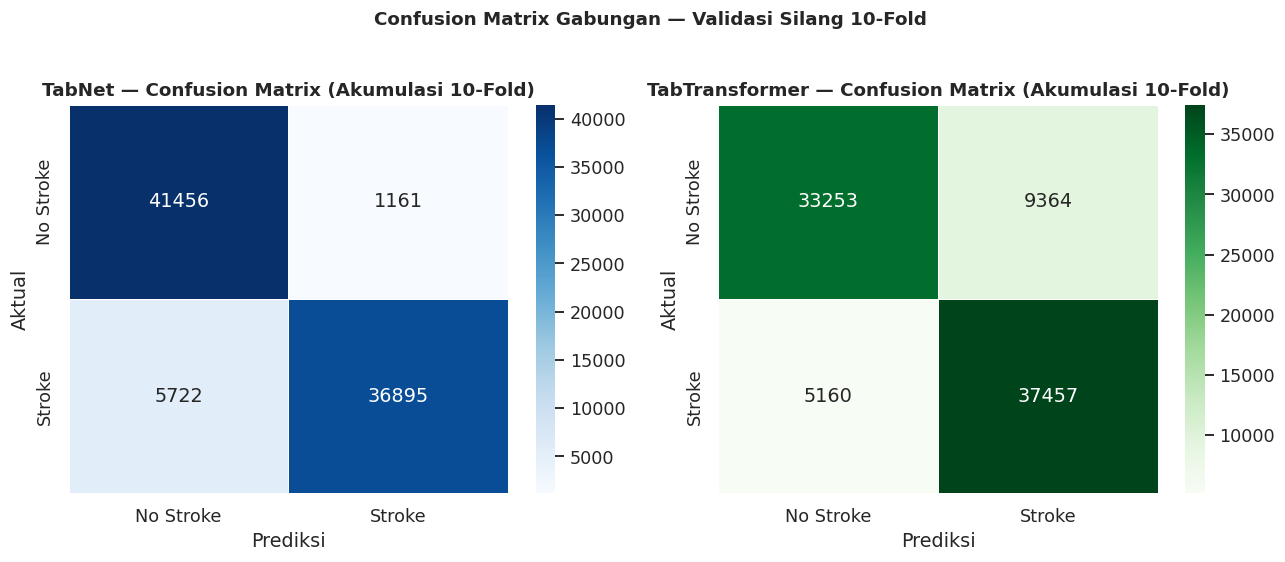

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (mdl, cmap) in zip(axes, [('TabNet', 'Blues'), ('TabTransformer', 'Greens')]):
    yt = np.array(accum[mdl]['y_true'])
    yp = np.array(accum[mdl]['y_pred'])
    sns.heatmap(confusion_matrix(yt, yp), annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['No Stroke','Stroke'],
                yticklabels=['No Stroke','Stroke'],
                linewidths=0.5, linecolor='white')
    ax.set_title(f'{mdl} — Confusion Matrix (Akumulasi {N_SPLITS}-Fold)', **FT)
    ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')

plt.suptitle(f'Confusion Matrix Gabungan — Validasi Silang {N_SPLITS}-Fold', **FT, y=1.02)
plt.tight_layout()
plt.show()

## Evaluasi: Perbandingan Metrik (Bar Chart)

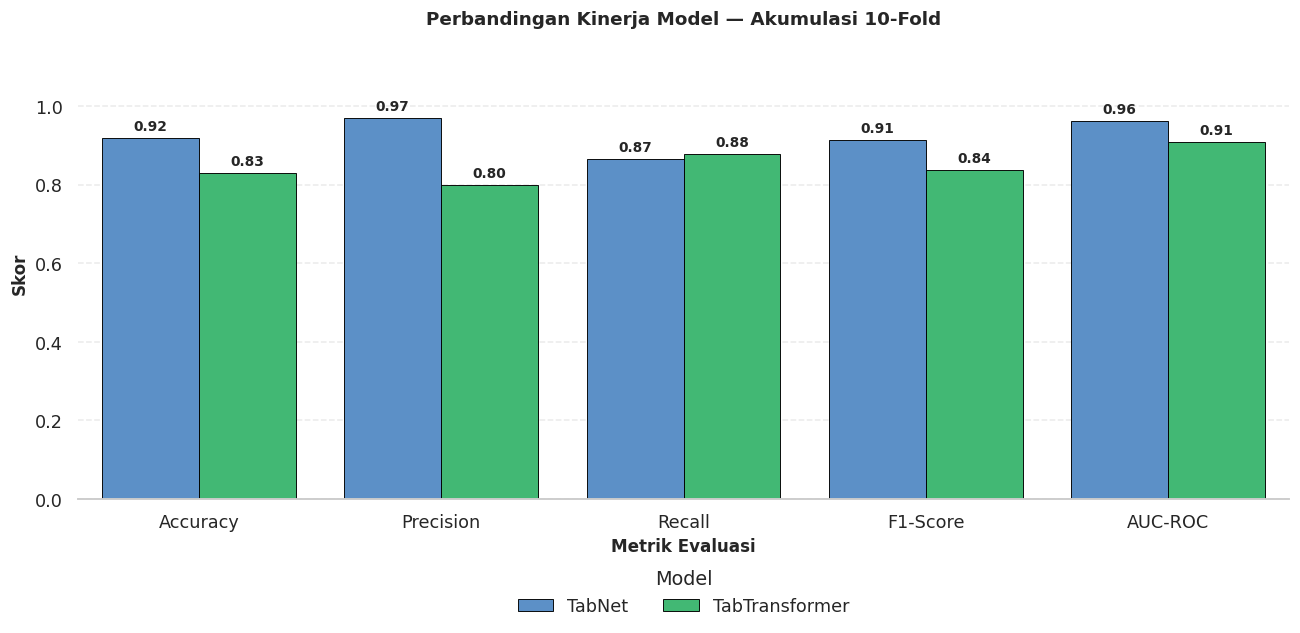

In [ ]:
rows = []
for mdl in MODELS:
    yt  = np.array(accum[mdl]['y_true'])
    yp  = np.array(accum[mdl]['y_pred'])
    yp_ = np.array(accum[mdl]['y_prob'])
    for mk, val in [('Accuracy',  accuracy_score(yt, yp)),
                    ('Precision', precision_score(yt, yp, zero_division=0)),
                    ('Recall',    recall_score(yt, yp, zero_division=0)),
                    ('F1-Score',  f1_score(yt, yp, zero_division=0)),
                    ('AUC-ROC',   roc_auc_score(yt, yp_))]:
        rows.append({'Model': mdl, 'Metrik': mk, 'Skor': val})

df_bar = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=df_bar, x='Metrik', y='Skor', hue='Model',
    palette={m: CLR[m] for m in MODELS}, ax=ax,
    edgecolor='black', linewidth=0.6
)

# Label angka dengan 2 desimal, ditempatkan jelas di atas bar
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f', fontsize=9, padding=3, fontweight='bold')

# Grid horizontal tipis di belakang bar agar lebih mudah dibaca
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

# Perjelas judul & label sumbu
ax.set_title(f'Perbandingan Kinerja Model — Akumulasi {N_SPLITS}-Fold', **FT, pad=15)
ax.set_xlabel('Metrik Evaluasi', fontsize=11, fontweight='bold')
ax.set_ylabel('Skor', fontsize=11, fontweight='bold')

# Bersihkan border yang tidak perlu
sns.despine(ax=ax, left=True)

ax.set_ylim(0, 1.15)
ax.legend(title='Model', loc='upper center', bbox_to_anchor=(0.5, -0.12),
          ncol=len(MODELS), frameon=False)

plt.tight_layout()
plt.show()

## Evaluasi: Kurva ROC

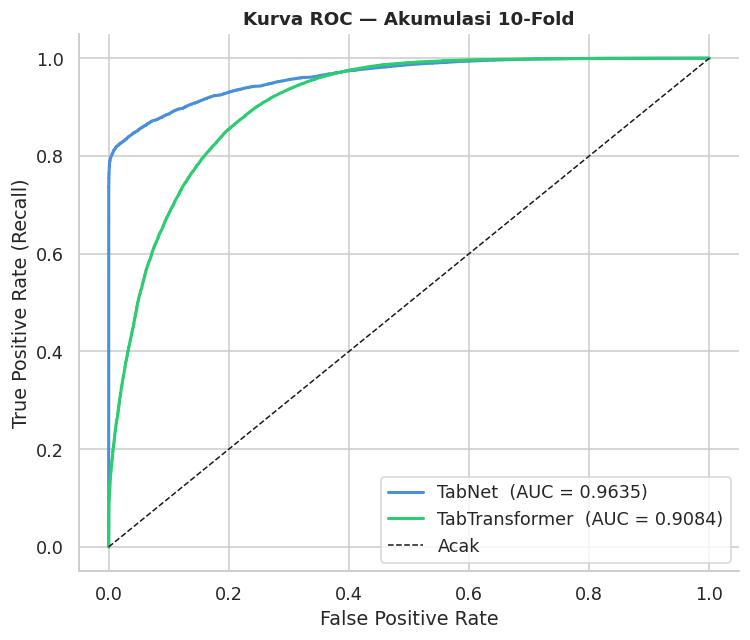

In [ ]:
plt.figure(figsize=(7, 6))
for mdl in MODELS:
    yt  = np.array(accum[mdl]['y_true'])
    yp_ = np.array(accum[mdl]['y_prob'])
    fpr, tpr, _ = roc_curve(yt, yp_)
    plt.plot(fpr, tpr, lw=2, color=CLR[mdl],
             label=f"{mdl}  (AUC = {roc_auc_score(yt, yp_):.4f})")

plt.plot([0,1],[0,1],'k--',lw=1,label='Acak')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate (Recall)')
plt.title(f'Kurva ROC — Akumulasi {N_SPLITS}-Fold', **FT)
plt.legend()
plt.tight_layout()
plt.show()

## Evaluasi: Stabilitas F1 per Fold

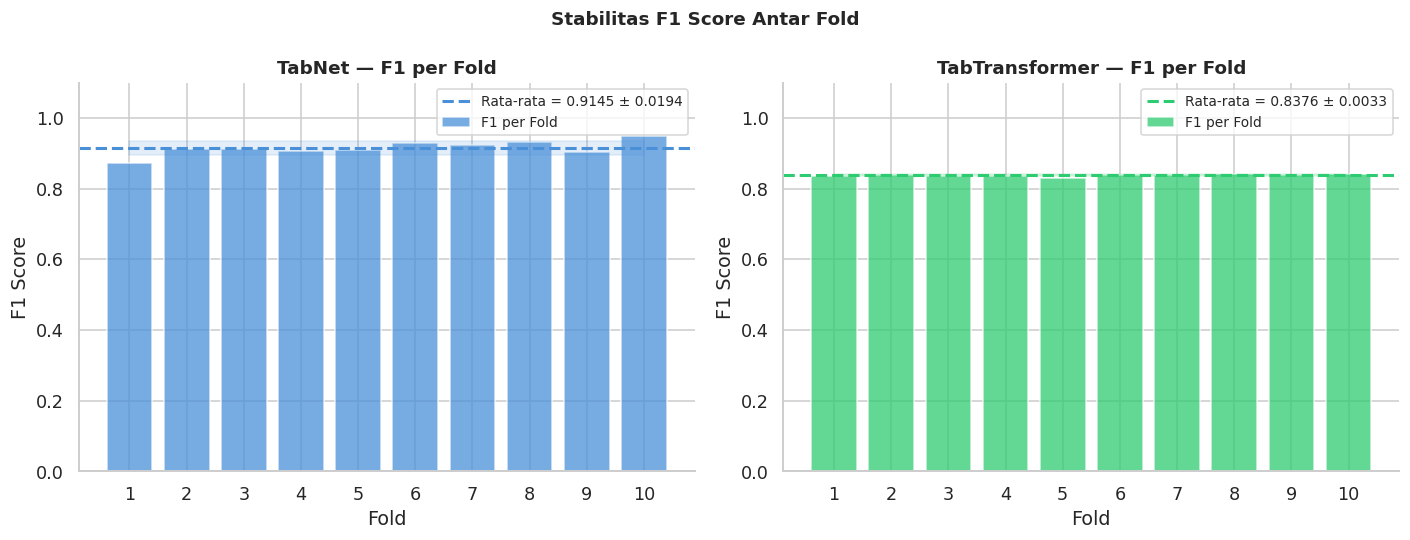

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
folds_x   = list(range(1, N_SPLITS + 1))
for ax, mdl in zip(axes, MODELS):
    f1s    = [r['F1'] for r in fold_metrics[mdl]]
    mu, sd = np.mean(f1s), np.std(f1s)
    ax.bar(folds_x, f1s, color=CLR[mdl], alpha=0.75, label='F1 per Fold')
    ax.axhline(mu, color=CLR[mdl], ls='--', lw=2,
               label=f'Rata-rata = {mu:.4f} \u00b1 {sd:.4f}')
    ax.fill_between(folds_x, [mu-sd]*N_SPLITS, [mu+sd]*N_SPLITS,
                    alpha=0.15, color=CLR[mdl])
    ax.set_title(f'{mdl} — F1 per Fold', **FT)
    ax.set_xlabel('Fold'); ax.set_ylabel('F1 Score')
    ax.set_ylim(0, 1.1); ax.set_xticks(folds_x); ax.legend(fontsize=9)

plt.suptitle('Stabilitas F1 Score Antar Fold', **FT)
plt.tight_layout()
plt.show()

## Evaluasi: Grafik RAM per Fold

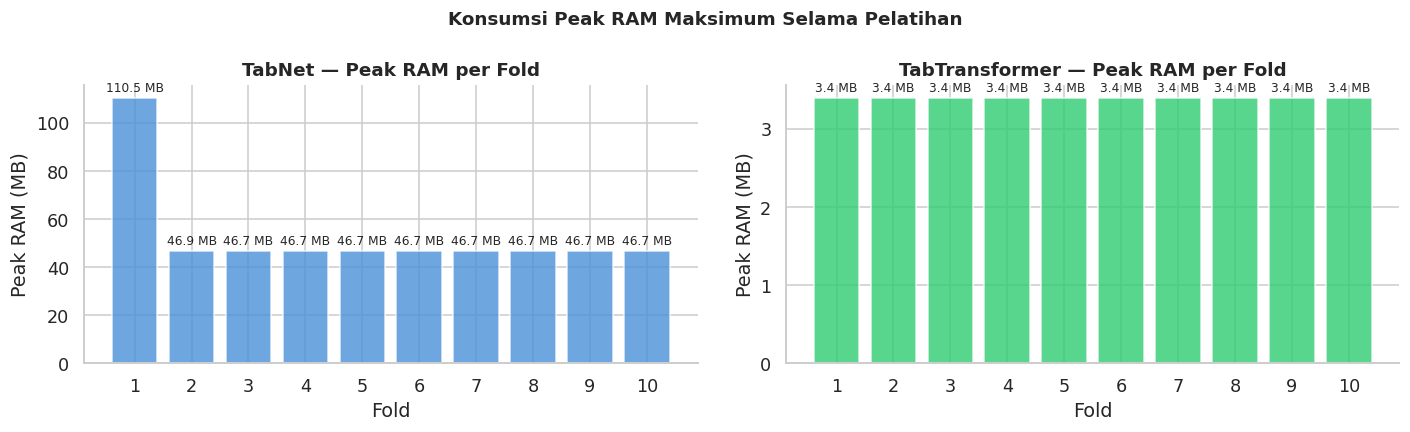

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, mdl in zip(axes, MODELS):
    peaks = [m['ram_peak'] for m in mem_log[mdl]]
    bars = ax.bar(folds_x, peaks, color=CLR[mdl], alpha=0.8, edgecolor='white')
    ax.bar_label(bars, fmt='%.1f MB', padding=2, fontsize=8)
    ax.set_title(f'{mdl} — Peak RAM per Fold', **FT)
    ax.set_xlabel('Fold'); ax.set_ylabel('Peak RAM (MB)'); ax.set_xticks(folds_x)

plt.suptitle('Konsumsi Peak RAM Maksimum Selama Pelatihan', **FT)
plt.tight_layout(); plt.show()

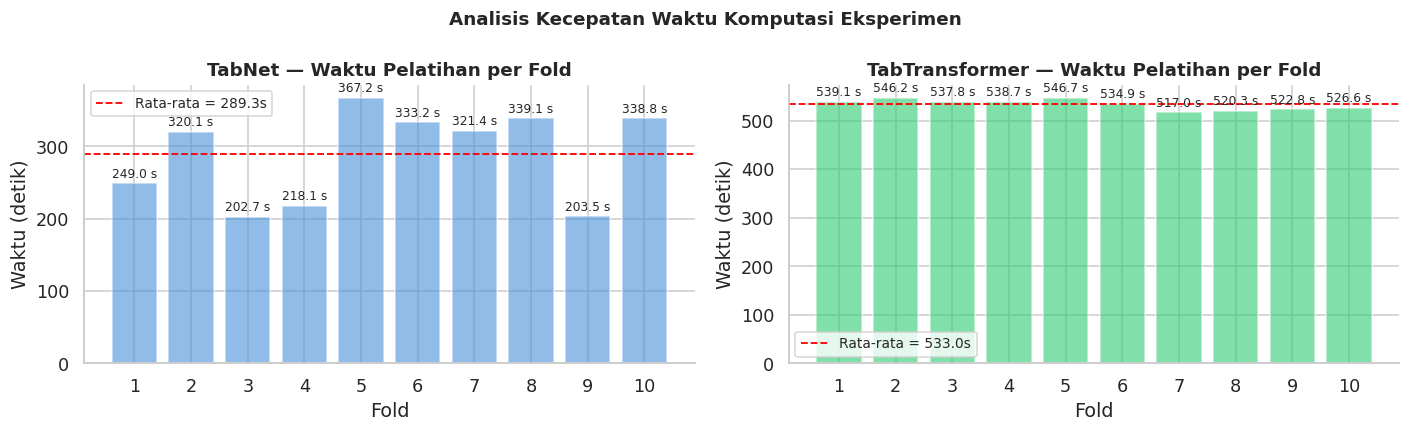

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, mdl in zip(axes, MODELS):
    times = [r['Time'] for r in fold_metrics[mdl]]
    mu_t  = np.mean(times)
    bars  = ax.bar(folds_x, times, color=CLR[mdl], alpha=0.6, edgecolor='white')
    ax.bar_label(bars, fmt='%.1f s', padding=2, fontsize=8)

    # Menambahkan garis rata-rata waktu komputasi
    ax.axhline(mu_t, color='red', ls='--', lw=1.2, label=f'Rata-rata = {mu_t:.1f}s')
    ax.set_title(f'{mdl} — Waktu Pelatihan per Fold', **FT)
    ax.set_xlabel('Fold'); ax.set_ylabel('Waktu (detik)'); ax.set_xticks(folds_x)
    ax.legend(fontsize=9)

plt.suptitle('Analisis Kecepatan Waktu Komputasi Eksperimen', **FT)
plt.tight_layout(); plt.show()

## Tabel Ringkasan Kinerja Akhir

In [ ]:
MKEYS = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
SEP   = '\u2550' * 72

print(f'\n{SEP}')
print(f'  TABEL RINGKASAN KINERJA MODEL (Akumulasi {N_SPLITS}-Fold)')
print(f'{SEP}')

summary = []
for mdl in MODELS:
    yt  = np.array(accum[mdl]['y_true'])
    yp  = np.array(accum[mdl]['y_pred'])
    yp_ = np.array(accum[mdl]['y_prob'])
    summary.append({
        'Model':     mdl,
        'Accuracy':  f"{accuracy_score(yt, yp):.4f}",
        'Precision': f"{precision_score(yt, yp, zero_division=0):.4f}",
        'Recall':    f"{recall_score(yt, yp, zero_division=0):.4f}",
        'F1-Score':  f"{f1_score(yt, yp, zero_division=0):.4f}",
        'AUC-ROC':   f"{roc_auc_score(yt, yp_):.4f}",
    })

df_summary = pd.DataFrame(summary).set_index('Model')
print(df_summary.to_string())


════════════════════════════════════════════════════════════════════════
  TABEL RINGKASAN KINERJA MODEL (Akumulasi 10-Fold)
════════════════════════════════════════════════════════════════════════
               Accuracy Precision  Recall F1-Score AUC-ROC
Model                                                     
TabNet           0.9192    0.9695  0.8657   0.9147  0.9635
TabTransformer   0.8296    0.8000  0.8789   0.8376  0.9084


##  Tabel Rata-rata ± Simpangan Baku per Fold

In [ ]:
print(f"\n{'─'*72}")
print('  RATA-RATA \u00b1 SIMPANGAN BAKU PER FOLD')
print(f"{'─'*72}")

meanstd = []
for mdl in MODELS:
    row = {'Model': mdl}
    for mk in MKEYS:
        vals    = [r[mk] for r in fold_metrics[mdl]]
        row[mk] = f'{np.mean(vals):.4f} \u00b1 {np.std(vals):.4f}'
    meanstd.append(row)

print(pd.DataFrame(meanstd).set_index('Model').to_string())


────────────────────────────────────────────────────────────────────────
  RATA-RATA ± SIMPANGAN BAKU PER FOLD
────────────────────────────────────────────────────────────────────────
                       Accuracy        Precision           Recall               F1              AUC
Model                                                                                              
TabNet          0.9192 ± 0.0178  0.9697 ± 0.0184  0.8657 ± 0.0271  0.9145 ± 0.0194  0.9730 ± 0.0071
TabTransformer  0.8296 ± 0.0026  0.8002 ± 0.0086  0.8789 ± 0.0151  0.8376 ± 0.0033  0.9086 ± 0.0012


## Tabel Konsumsi Sumber Daya (RAM / VRAM)

In [ ]:
print(f"\n{'─'*75}\n  TABEL RINGKASAN SUMBER DAYA & WAKTU KOMPUTASI (5-Fold CV)\n{'─'*75}")
resource_rows = []
for mdl in MODELS:
    ram_peaks = [m['ram_peak'] for m in mem_log[mdl]]
    times     = [r['Time']     for r in fold_metrics[mdl]]

    row = {'Model': mdl,
           'Rata-rata Waktu/Fold (s)': f'{np.mean(times):.2f} ± {np.std(times):.2f}',
           'Total Waktu 5-Fold (s)':   f'{np.sum(times):.2f}',
           'Maksimum Peak RAM (MB)':   f'{np.max(ram_peaks):.1f}'}

    if DEVICE == 'cuda':
        vram_peaks = [m['vram_peak'] or 0 for m in mem_log[mdl]]
        row['Maksimum Peak VRAM (MB)'] = f'{np.max(vram_peaks):.1f}'

    resource_rows.append(row)

print(pd.DataFrame(resource_rows).set_index('Model').to_string())
print(f"\n{'\u2550'*75}")


───────────────────────────────────────────────────────────────────────────
  TABEL RINGKASAN SUMBER DAYA & WAKTU KOMPUTASI (5-Fold CV)
───────────────────────────────────────────────────────────────────────────
               Rata-rata Waktu/Fold (s) Total Waktu 5-Fold (s) Maksimum Peak RAM (MB) Maksimum Peak VRAM (MB)
Model                                                                                                        
TabNet                   289.30 ± 60.38                2893.03                  110.5                    96.1
TabTransformer           533.01 ± 10.10                5330.11                    3.4                   102.9

═══════════════════════════════════════════════════════════════════════════


## Classification Report Lengkap

In [ ]:
for mdl in MODELS:
    yt = np.array(accum[mdl]['y_true'])
    yp = np.array(accum[mdl]['y_pred'])
    print(f'\n  CLASSIFICATION REPORT — {mdl}')
    print('─' * 50)
    print(classification_report(yt, yp,
          target_names=['No Stroke', 'Stroke'], digits=4))


  CLASSIFICATION REPORT — TabNet
──────────────────────────────────────────────────
              precision    recall  f1-score   support

   No Stroke     0.8787    0.9728    0.9233     42617
      Stroke     0.9695    0.8657    0.9147     42617

    accuracy                         0.9192     85234
   macro avg     0.9241    0.9192    0.9190     85234
weighted avg     0.9241    0.9192    0.9190     85234


  CLASSIFICATION REPORT — TabTransformer
──────────────────────────────────────────────────
              precision    recall  f1-score   support

   No Stroke     0.8657    0.7803    0.8208     42617
      Stroke     0.8000    0.8789    0.8376     42617

    accuracy                         0.8296     85234
   macro avg     0.8328    0.8296    0.8292     85234
weighted avg     0.8328    0.8296    0.8292     85234

